Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


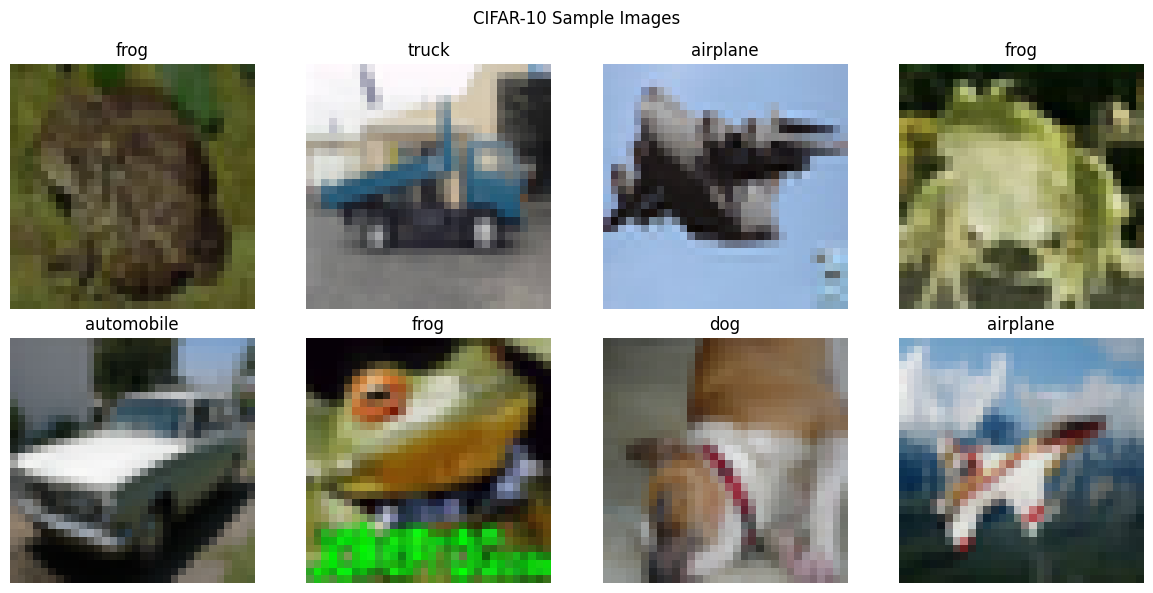


Using device: cpu

Starting Training...

Epoch [1/10], Loss: 1.4404
Epoch [2/10], Loss: 1.0988
Epoch [3/10], Loss: 0.9481
Epoch [4/10], Loss: 0.8457
Epoch [5/10], Loss: 0.7665
Epoch [6/10], Loss: 0.6988
Epoch [7/10], Loss: 0.6376
Epoch [8/10], Loss: 0.5720
Epoch [9/10], Loss: 0.5140
Epoch [10/10], Loss: 0.4565

TEST RESULTS
Correct Predictions: 7002
Total Images: 10000
Accuracy on test data: 70.02%


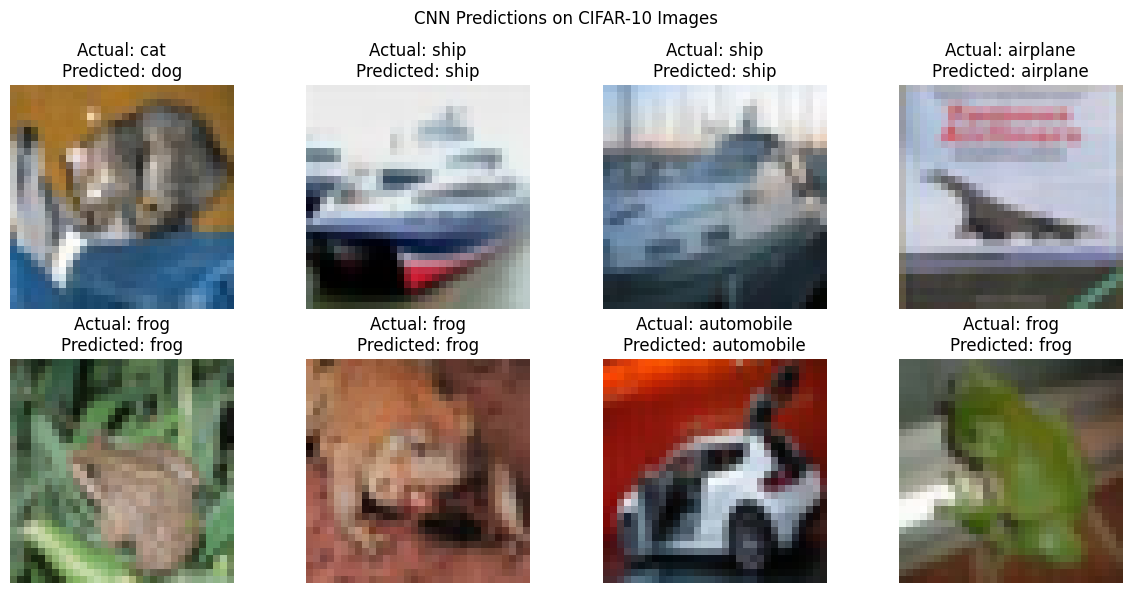

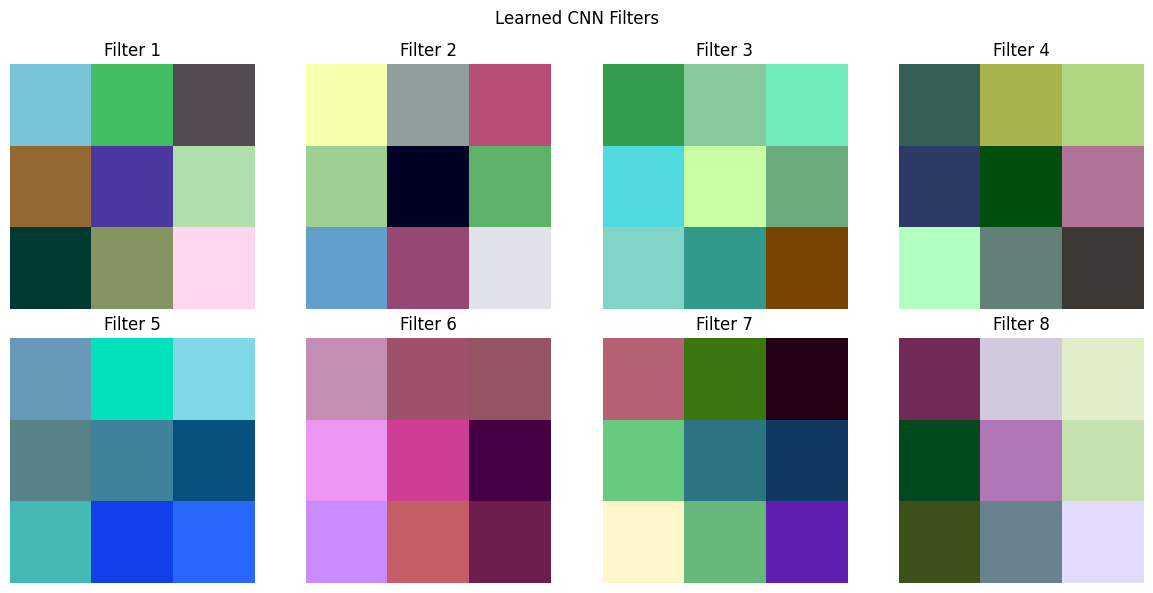


CNN TRAINING COMPLETED
Dataset       : CIFAR-10
CNN Model     : SimpleCNN
Epochs        : 10
Batch Size    : 64
Learning Rate : 0.001
Test Accuracy : 70.02%


In [4]:
# ============================================================
# CIFAR-10 IMAGE CLASSIFICATION USING CNN
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. LOAD AND PREPROCESS CIFAR-10 DATASET
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = trainset.classes

print("Classes:")
print(classes)


# ============================================================
# 2. DISPLAY SAMPLE CIFAR-10 IMAGES
# ============================================================

dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    # Unnormalize image
    img = images[i] / 2 + 0.5

    # Convert tensor to NumPy
    npimg = img.numpy()

    # Convert CHW to HWC
    npimg = np.transpose(npimg, (1, 2, 0))

    # Display image
    ax.imshow(npimg)

    # Display class name
    ax.set_title(classes[labels[i]])

    ax.axis('off')

plt.suptitle("CIFAR-10 Sample Images")
plt.tight_layout()
plt.show()


# ============================================================
# 3. DEFINE CNN ARCHITECTURE
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(
            3,
            16,
            3,
            padding=1
        )

        # Max pooling
        self.pool = nn.MaxPool2d(
            2,
            2
        )

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            16,
            32,
            3,
            padding=1
        )

        # Fully connected layer
        self.fc1 = nn.Linear(
            32 * 8 * 8,
            128
        )

        # Output layer
        self.fc2 = nn.Linear(
            128,
            10
        )

        # ReLU activation
        self.relu = nn.ReLU()


    def forward(self, x):

        # Conv1 → ReLU → Pool
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Conv2 → ReLU → Pool
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten
        x = x.view(
            -1,
            32 * 8 * 8
        )

        # Fully connected layer
        x = self.fc1(x)
        x = self.relu(x)

        # Output
        x = self.fc2(x)

        return x


# ============================================================
# 4. CREATE MODEL
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nUsing device:", device)

model = SimpleCNN().to(device)


# ============================================================
# 5. LOSS FUNCTION AND OPTIMIZER
# ============================================================

lossfn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# ============================================================
# 6. TRAIN THE CNN
# ============================================================

num_epochs = 10

print("\nStarting Training...\n")

for epoch in range(num_epochs):

    running_loss = 0.0

    for inputs, labels in trainloader:

        # Move data to CPU/GPU
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(inputs)

        # Calculate loss
        loss = lossfn(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = (
        running_loss / len(trainloader)
    )

    print(
        "Epoch [{}/{}], Loss: {:.4f}".format(
            epoch + 1,
            num_epochs,
            average_loss
        )
    )


# ============================================================
# 7. TEST THE MODEL
# ============================================================

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        # Prediction
        outputs = model(images)

        # Select class with highest score
        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


accuracy = 100 * correct / total

print("\n================================")
print("TEST RESULTS")
print("================================")

print(
    "Correct Predictions:",
    correct
)

print(
    "Total Images:",
    total
)

print(
    "Accuracy on test data: {:.2f}%".format(
        accuracy
    )
)


# ============================================================
# 8. DISPLAY TEST IMAGES WITH PREDICTIONS
# ============================================================

dataiter = iter(testloader)
images, labels = next(dataiter)

images_gpu = images.to(device)

with torch.no_grad():

    outputs = model(images_gpu)

    _, predicted = torch.max(
        outputs,
        1
    )


fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)

for i, ax in enumerate(axes.flat):

    # Unnormalize
    img = images[i] / 2 + 0.5

    # Convert to NumPy
    npimg = img.numpy()

    # CHW → HWC
    npimg = np.transpose(
        npimg,
        (1, 2, 0)
    )

    # Display image
    ax.imshow(npimg)

    actual = classes[labels[i]]
    prediction = classes[predicted[i].cpu()]

    ax.set_title(
        "Actual: {}\nPredicted: {}".format(
            actual,
            prediction
        )
    )

    ax.axis('off')

plt.suptitle(
    "CNN Predictions on CIFAR-10 Images"
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZE LEARNED CONVOLUTION FILTERS
# ============================================================

def visualize_filters(layer, n_filters=8):

    filters = (
        layer.weight.data
        .clone()
        .cpu()
    )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(12, 6)
    )

    for i, ax in enumerate(axes.flat):

        f = filters[i]

        # Normalize filter
        f = (
            f - f.min()
        ) / (
            f.max() - f.min() + 1e-8
        )

        # Convert CHW → HWC
        f = f.permute(
            1,
            2,
            0
        )

        ax.imshow(f)

        ax.set_title(
            "Filter {}".format(i + 1)
        )

        ax.axis('off')

    plt.suptitle(
        "Learned CNN Filters"
    )

    plt.tight_layout()
    plt.show()


# Display filters from first convolution layer
visualize_filters(
    model.conv1,
    8
)


# ============================================================
# 10. FINAL OUTPUT
# ============================================================

print("\n================================")
print("CNN TRAINING COMPLETED")
print("================================")

print("Dataset       : CIFAR-10")
print("CNN Model     : SimpleCNN")
print("Epochs        :", num_epochs)
print("Batch Size    : 64")
print("Learning Rate : 0.001")
print(
    "Test Accuracy : {:.2f}%".format(
        accuracy
    )
)